# Almgren-Chriss Model and Extensions
**Electronic Markets - 2026**  
Authors: Benjamin Fernandes Neres, Dorian Deilhes, Ben Komara

---

This notebook covers the three sections of the project:
- **Section 1**: IS, TC and TWAP optimal strategies - closed-form solutions, efficient frontiers, Bellman grid
- **Section 2**: Euler scheme and shooting method for the Euler-Lagrange boundary value problem
- **Section 3**: Optimal liquidation of two correlated assets

All logic lives in `src/`. This notebook only calls functions and displays results.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Add 'src' directory to Python path so modules can be imported
sys.path.insert(0, os.path.join(os.getcwd(), 'src'))

from almgren_chriss import (
    optimal_strategy_is,
    optimal_strategy_tc,
    optimal_strategy_twap,
    cost_and_variance_is,
    cost_and_variance_tc,
    efficient_frontier_is,
    efficient_frontier_tc,
)
from bellman import bellman_is, bellman_tc
from euler_shooting import euler_solve, shooting_method
from two_assets import bellman_two_assets

# Global plot style
plt.rcParams.update({
    'figure.figsize': (9, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
})

---
## Section 1 : IS, TC and TWAP orders

### Model recap

A trader holds $Q$ shares of a risky asset $S$ and must liquidate by time $T$.

**State variables:**
- $q_t$: remaining inventory, with $q_0 = Q$ and $q_T = 0$
- $v_t = -\dot{q}_t$: selling rate (control)
- $dS_t = \sigma\,dW_t$ — no permanent market impact in this project
- Temporary market impact: $h(v) = \eta v$ (Assume linear temporary market impact)

**Three benchmarks:**

| Order | Benchmark | Variance penalises |
|-------|-----------|--------------------|
| IS | $S_0$ | $\sigma^2\int_0^T q_t^2\,dt$ |
| TC | $S_T$ | $\sigma^2\int_0^T (q_t-Q)^2\,dt$ |
| TWAP | $\frac{1}{T}\int_0^T S_t\,dt$ | $\sigma^2\int_0^T (q_t - Q\frac{T-t}{T})^2\,dt$ |

In [2]:
# ── Shared model parameters ────────────────────────────────────────────────
Q     = 1.0    # initial inventory (normalised to 1)
T     = 1.0    # liquidation horizon (in days or any consistent unit)
sigma = 0.5    # asset volatility
eta   = 0.01    # temporary market impact coefficient
lam   = 1.0    # risk-aversion coefficient (lambda)

### Question 1 : Optimal static strategies (closed form)

The mean-variance problem reduces to:
$$\min_q \int_0^T \left[\eta\dot{q}^2 + \lambda\sigma^2\cdot\text{penalty}(q_t)\right]dt$$

Setting $\kappa = \sqrt{\lambda\sigma^2/\eta}$, the Euler-Lagrange equation gives:

- **IS**: $q^*(t) = Q\,\dfrac{\sinh(\kappa(T-t))}{\sinh(\kappa T)}$ — front-loaded (sell fast early to reduce risk)
- **TC**: $q^*(t) = Q\left(1 - \dfrac{\sinh(\kappa t)}{\sinh(\kappa T)}\right)$ — back-loaded (wait for the closing price)
- **TWAP**: $q^*(t) = Q\dfrac{T-t}{T}$ — always linear, independent of $\lambda$

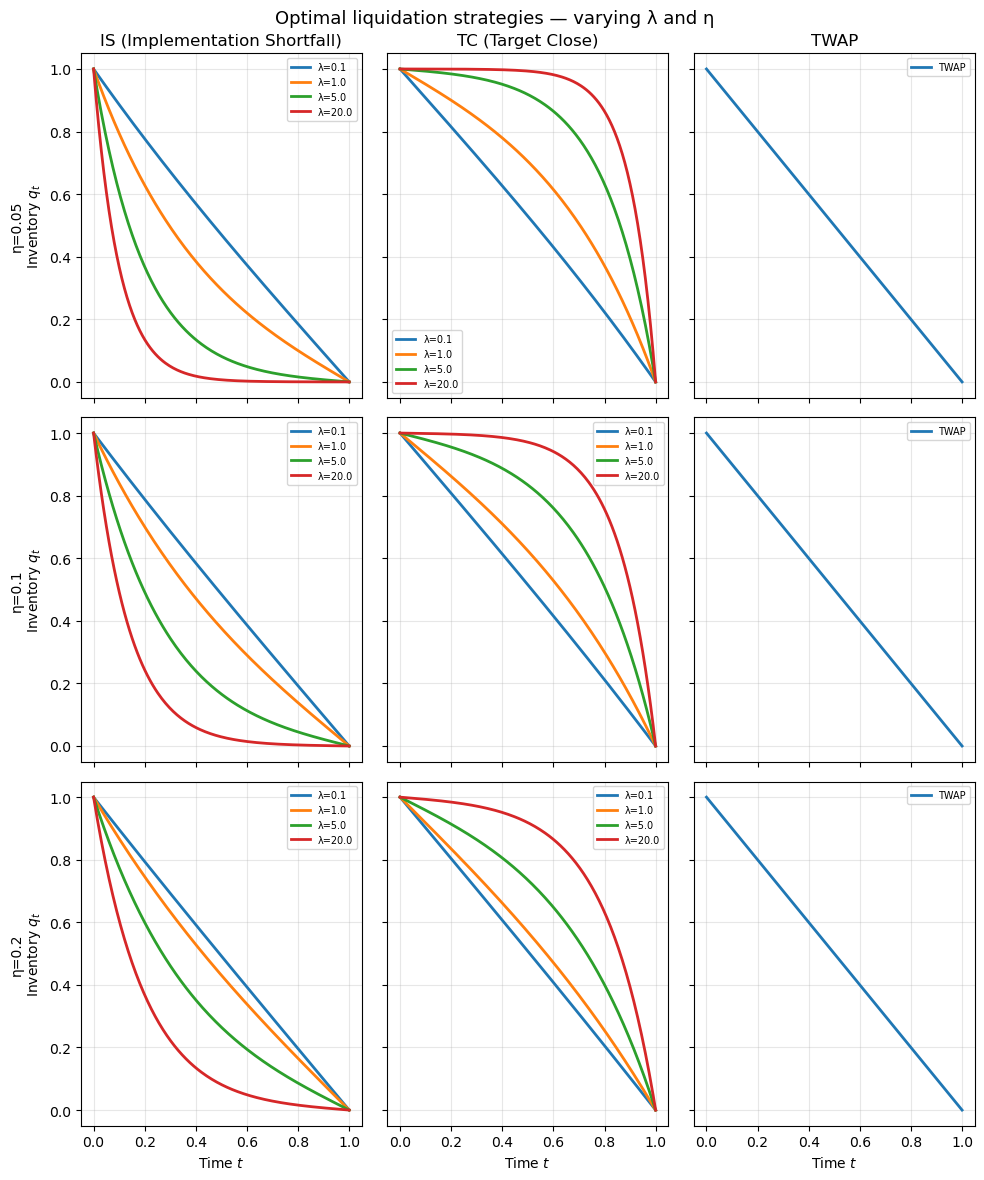

In [ ]:
# Compare optimal strategies for different risk aversions (λ) and temporary impact (η)

# Values of λ (risk aversion) and η (temporary impact) to explore
lambdas_plot = [0.1, 1.0, 5.0, 20.0]
etas_plot     = [0.05, 0.1, 0.2] 

# Colors for different λ on each subplot
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
titles = ['IS (Implementation Shortfall)', 'TC (Target Close)', 'TWAP']

fig, axes = plt.subplots(
    len(etas_plot), len(titles), figsize=(10, 4 * len(etas_plot)), sharex=True, sharey=True
)

for row, eta_i in enumerate(etas_plot):
    for col, order_type in enumerate(['IS', 'TC', 'TWAP']):
        ax = axes[row, col]

        if order_type in ['IS', 'TC']:
            # For IS / TC: plot one curve per λ
            for lam_i, color in zip(lambdas_plot, colors):
                if order_type == 'IS':
                    t_i, q_i, _ = optimal_strategy_is(Q, T, sigma, eta_i, lam_i)
                else:
                    t_i, q_i, _ = optimal_strategy_tc(Q, T, sigma, eta_i, lam_i)

                ax.plot(t_i, q_i, color=color, label=f'λ={lam_i}')
        else:
            # TWAP does not depend on λ or η
            t_tw, q_tw, _ = optimal_strategy_twap(Q, T)
            ax.plot(t_tw, q_tw, color='tab:blue', label='TWAP')

        # Cosmetics
        if row == 0:
            ax.set_title(titles[col])
        if col == 0:
            ax.set_ylabel(f'η={eta_i}\nInventory $q_t$')
        if row == len(etas_plot) - 1:
            ax.set_xlabel('Time $t$')

        ax.legend(fontsize=7)

fig.suptitle('Optimal liquidation strategies — varying λ and η', fontsize=13)
plt.tight_layout()
plt.show()

**When we vary $\eta$ (the temporary market impact):**
- For small $\eta$ (cheap to trade), all optimal strategies become more *curved*: the IS schedule sells very fast at the beginning, and the TC schedule delays even more towards the end, because trading costs are low.
- For large $\eta$ (expensive to trade), all strategies become closer to **linear**: the trader spreads trades more evenly over $[0,T]$ to avoid paying too much temporary impact.

**When we vary $\lambda$ (the risk aversion):**
- IS is front-loaded: the higher $\lambda$, the more aggressively the trader sells early to reduce inventory risk.
- TC is back-loaded: the trader waits to sell close to $T$ to track the closing price $S_T$.
- TWAP is always linear — the TWAP benchmark and the linear schedule are perfectly aligned, so any $\lambda$ gives the same solution.

### Question 2 : Efficient frontiers

For each $\lambda$, the optimal strategy defines a (cost, variance) pair.
Sweeping $\lambda$ traces the **efficient frontier**: the set of Pareto-optimal strategies.

<Figure size 900x500 with 0 Axes>

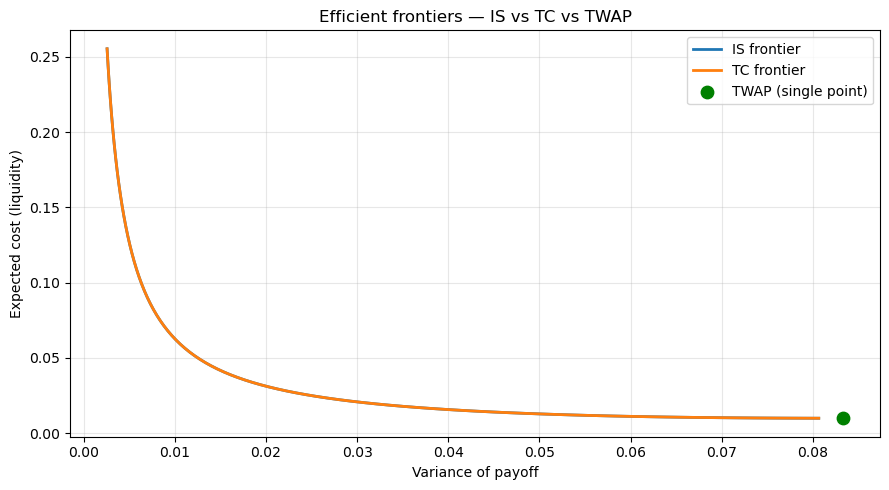

In [4]:
# Sweep lambda from near-zero (risk-neutral) to large (very risk-averse)
plt.figure()
lambdas = np.logspace(-2, 2, 100)

costs_is, vars_is = efficient_frontier_is(Q, T, sigma, eta, lambdas)
costs_tc, vars_tc = efficient_frontier_tc(Q, T, sigma, eta, lambdas)

# TWAP is a single point (lambda-independent)
t_tw, q_tw, v_tw = optimal_strategy_twap(Q, T)
cost_tw, var_tw = cost_and_variance_is(q_tw, v_tw, t_tw, sigma, eta)

plt.figure()
plt.plot(vars_is, costs_is, label='IS frontier')
plt.plot(vars_tc, costs_tc, label='TC frontier')
plt.scatter([var_tw], [cost_tw], color='green', zorder=5, s=80, label='TWAP (single point)')
plt.xlabel('Variance of payoff')
plt.ylabel('Expected cost (liquidity)')
plt.title('Efficient frontiers — IS vs TC vs TWAP')
plt.legend()
plt.tight_layout()
plt.show()

**Reading the frontier:**
- Moving right along the frontier = lower $\lambda$ (more risk-tolerant): slower liquidation, lower cost, higher variance.
- Moving left = higher $\lambda$ (more risk-averse): faster liquidation, higher cost, lower variance.
- TWAP corresponds to a specific ($\lambda$-independent) point on or near the IS frontier.

**Why are IS and TC frontiers similar?**

For both benchmarks, the frontier is the curve $(\text{Risk}^\star, \text{Cost}^\star)$ parametrized by $\kappa = \sqrt{\lambda\sigma^2/\eta} > 0$:

$$
\text{Cost}^\star = \frac{\eta Q^2 \kappa}{2}\coth(\kappa T), \qquad
\text{Risk}^\star = \frac{\sigma^2 Q^2}{2\kappa^2}\Bigl(\kappa T\coth(\kappa T) - 1\Bigr).
$$

**The two frontiers are identical.** This follows from the fact that IS and TC are time-reverses of each other,
$$
q_{\mathrm{TC}}(t) = Q - q_{\mathrm{IS}}(T-t),
$$
so the cost and risk integrals — being integrated over the full horizon $[0,T]$ — take the same value under the substitution $t \mapsto T - t$.

---

### Question 3 (Bonus) : Expected utility Framework

We reformulated the **TC** and **TWAP** liquidation problems in the expected-utility setting with CARA utility
$$U(x)=-e^{-\gamma x}.$$ 
The key difference between the two benchmarks is the number of primitive state variables in the HJB:
- **TC** uses $(t,x,S,q)$ because the benchmark is the terminal price $S_T$.
- **TWAP** uses $(t,x,S,A,q)$ with $$A_t=\frac{1}{T}\int_0^t S_u\,du$$ because the benchmark depends on the whole price path.

Using an exponential ansatz, both HJBs reduce to deterministic quadratic control problems. Since we restrict attention to **deterministic strategies**, the payoff is Gaussian: it is the sum of a deterministic impact term and a stochastic integral with deterministic integrand. Therefore the CARA expected-utility criterion is equivalent to the mean-variance objective with the identification
$$\lambda=\frac{\gamma}{2}.$$ 

As a consequence, the optimal strategies are the same as in the mean-variance framework after replacing $\lambda$ by $\gamma/2$:
- **TC**: $$q_{\mathrm{TC}}^*(t)=Q\left(1-\frac{\sinh(\kappa t)}{\sinh(\kappa T)}\right),$$
- **TWAP**: $$q_{\mathrm{TWAP}}^*(t)=Q\frac{T-t}{T},$$
with
$$\kappa=\sqrt{\frac{\gamma\sigma^2}{2\eta}}.$$
---

### Question 4 : Bellman equation on a discrete grid (IS and TC)

#### Connection to the "Mini Game 2" 

Recall the class example: you have a bag with $Q$ rocks. At each time step, you throw some rocks and suffer two types of pain:
- **Throwing pain:** pain = (number of rocks thrown)²  
- **Holding pain:** pain = (number of rocks in bag)²

You want to minimize total pain over all steps.

This is **exactly** the IS liquidation problem:
- **Throwing rocks** = selling shares (incurs market impact cost $\propto v_t^2$)
- **Holding rocks** = keeping shares in inventory (incurs price risk $\propto q_t^2$)
- **Goal:** choose how many shares to sell at each time step to minimize total cost + risk

The **Bellman equation** lets us solve this recursively by working backwards:
- At the last step, we must throw all remaining rocks (sell all remaining shares)
- At each earlier step, we decide: "How many should I throw now versus later?"
- The value function $V_k(q)$ = minimum total pain from step $k$ onwards, given $q$ rocks remaining

---

#### Discrete Bellman Equation Breakdown

The discrete problem (IS) is:
$$V_k(q) = \min_{0 \le n \le q}\left[\eta\left(\frac{n}{\Delta t}\right)^2\Delta t + \lambda\sigma^2 q^2 \Delta t + V_{k+1}(q-n)\right]$$
with $V_N(0)=0$, $V_N(q)=+\infty$ for $q>0$.

**What each term means:**

- **$V_k(q)$** = the optimal (minimum) total pain from time step $k$ to the end $N$, starting with $q$ shares to sell.

- **$n$** = the decision variable: how many shares to sell **at this step** (you choose the best $n$).

- **$\eta\left(\frac{n}{\Delta t}\right)^2\Delta t$** = **immediate throwing pain** (market impact cost)
  - You sell $n$ shares in time interval $\Delta t$
  - Velocity = $\frac{n}{\Delta t}$ (shares per unit time)
  - Impact cost is quadratic in velocity: $\eta v^2 \Delta t = \eta\left(\frac{n}{\Delta t}\right)^2 \Delta t$

- **$\lambda\sigma^2 q^2 \Delta t$** = **immediate holding pain** (price risk)
  - You hold $q$ shares at this time step
  - Price moves with volatility $\sigma$
  - Risk is quadratic in position: $\lambda\sigma^2 q^2 \Delta t$
  - The parameter $\lambda$ weights how much you care about risk vs. cost

- **$V_{k+1}(q-n)$** = **future optimal cost** (recursion)
  - After selling $n$ shares, you have $q-n$ left
  - The remaining cost from the next step onwards is $V_{k+1}(q-n)$
  - This is the Bellman **recursion**: today's decision feeds tomorrow's problem

- **$\min_{0 \le n \le q}$** = we choose $n$ optimally at each step to minimize total cost.

- **Boundary condition:** $V_N(0)=0$ (no pain if nothing left), $V_N(q)=+\infty$ for $q>0$ (impossible to finish early).

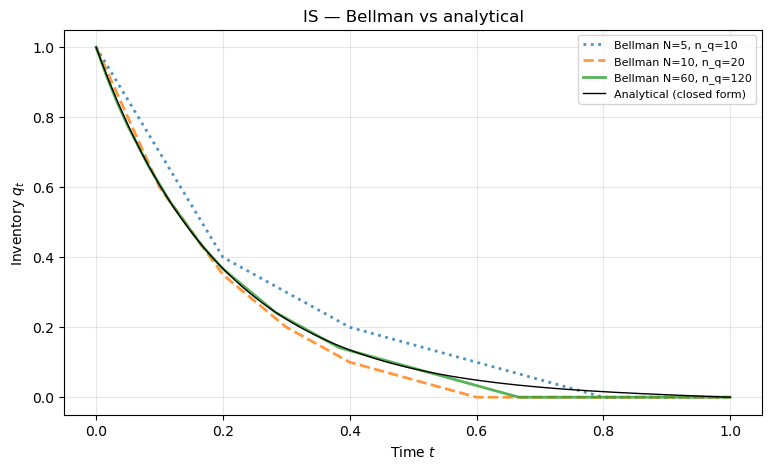

In [5]:

lam_bellman = 1.0   # fix lambda for the comparison

# Analytical solutions
t_is_exact, q_is_exact, _ = optimal_strategy_is(Q, T, sigma, eta, lam_bellman)
t_tc_exact, q_tc_exact, _ = optimal_strategy_tc(Q, T, sigma, eta, lam_bellman)


# Run Bellman for IS 
for N_grid, n_q_grid, style in [(5, 10, ':'), (10, 20, '--'), (60, 120, '-')]:
    label = f'Bellman N={N_grid}, n_q={n_q_grid}'

    t_b_is, _, q_b_is = bellman_is(Q, T, sigma, eta, lam_bellman, N=N_grid, n_q=n_q_grid)

    plt.plot(t_b_is, q_b_is, style, alpha=0.8, label=label)

# Overlay analytical solution
plt.plot(t_is_exact, q_is_exact, 'k-', linewidth=1, label='Analytical (closed form)')

plt.title('IS — Bellman vs analytical')

plt.xlabel('Time $t$')
plt.ylabel('Inventory $q_t$')
plt.legend(fontsize=8)


For the TC benchmark, the variance term penalises the deviation from the initial inventory $Q$, i.e. $(q_t - Q)^2$ instead of $q_t^2$.

The Discrete problem (TC):
$$V_k(q) = \min_{0 \le n \le q}\left[\eta\left(\frac{n}{\Delta t}\right)^2\Delta t + \lambda\sigma^2 (q - Q)^2 \Delta t + V_{k+1}(q-n)\right]$$


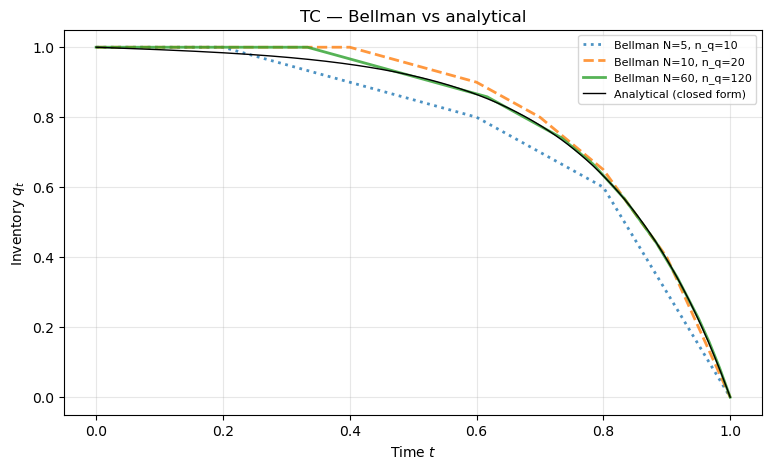

In [6]:

lam_bellman = 1.0   # fix lambda for the comparison

# Analytical solutions
t_is_exact, q_is_exact, _ = optimal_strategy_is(Q, T, sigma, eta, lam_bellman)
t_tc_exact, q_tc_exact, _ = optimal_strategy_tc(Q, T, sigma, eta, lam_bellman)


# Run Bellman for TC 
for N_grid, n_q_grid, style in [(5, 10, ':'), (10, 20, '--'), (60, 120, '-')]:
    label = f'Bellman N={N_grid}, n_q={n_q_grid}'

    t_b_tc, _, q_b_tc = bellman_tc(Q, T, sigma, eta, lam_bellman, N=N_grid, n_q=n_q_grid)

    plt.plot(t_b_tc, q_b_tc, style, alpha=0.8, label=label)

# Overlay analytical solution
plt.plot(t_tc_exact, q_tc_exact, 'k-', linewidth=1, label='Analytical (closed form)')

plt.title('TC — Bellman vs analytical')

plt.xlabel('Time $t$')
plt.ylabel('Inventory $q_t$')
plt.legend(fontsize=8)


---
## Section 2 : Euler Scheme and Shooting Method

### Question 1 : Euler-Lagrange as a first-order system

The IS mean-variance problem leads to the Euler-Lagrange (EL) equation:
$$\eta\,\ddot{q}(t) = \lambda\sigma^2\,q(t) \quad \Longleftrightarrow \quad \ddot{q} = \kappa^2 q$$

We rewrite this as a **first-order ODE system** with $v = -\dot{q}$ (selling rate):
$$\frac{d}{dt}\begin{pmatrix}q\\v\end{pmatrix} = \begin{pmatrix}0 & -1\\ -\kappa^2 & 0\end{pmatrix}\begin{pmatrix}q\\v\end{pmatrix}$$

Boundary conditions: $q(0)=Q$, $q(T)=0$.  
The problem: only $q(0)$ is known, not $v(0)$.

### Question 2 : Euler scheme

The first-order system with initial conditions $q_0 = Q$, $v_0 = v^i$ (free parameter):
$$q_{k+1} = q_k - \Delta t\cdot v_k$$
$$v_{k+1} = v_k - \Delta t\cdot \kappa^2\,q_k$$

We integrate the system numerically for several values of $v^i$ to visualise how $q(T)$ varies.

Using kappa = 5.0000 for Euler shooting method
Theoretical initial selling rate v0 = 5.0005


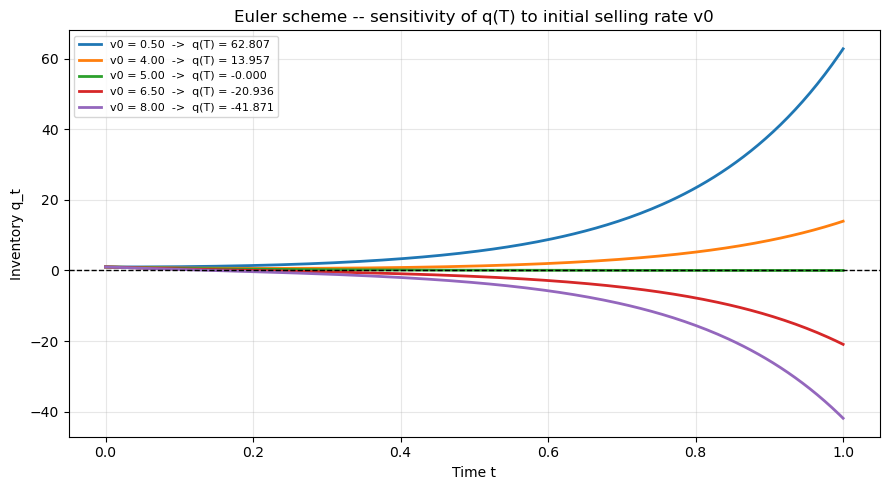

In [66]:
from almgren_chriss import _kappa  # kappa = sqrt(lambda * sigma^2 / eta)
#sigma = 0.3    # asset volatility for a better view of the shooting method convergence
#eta   = 0.1    # temporary market impact coefficient for a better view of the shooting method convergence
lam_euler = 1.0
N_euler   = 200
kap = _kappa(lam_euler, sigma, eta)
print(f"Using kappa = {kap:.4f} for Euler shooting method")
# Theoretical v0 for reference
if abs(kap * T) < 1e-8:
    v0_theory = Q / T
else:
    v0_theory = Q * kap / np.tanh(kap * T)

print(f"Theoretical initial selling rate v0 = {v0_theory:.4f}")

# Try different initial selling rates
v0_values = [v0_theory * f for f in [0.1, 0.8, 1.0, 1.3, 1.6]]

plt.figure()
for v0_i in v0_values:
    t_e, q_e, _ = euler_solve(Q, T, v0_i, kap, N_euler)
    plt.plot(t_e, q_e, label=f'v0 = {v0_i:.2f}  ->  q(T) = {q_e[-1]:.3f}')

plt.axhline(0, color='k', linewidth=1, linestyle='--')
plt.xlabel('Time t')
plt.ylabel('Inventory q_t')
plt.title('Euler scheme -- sensitivity of q(T) to initial selling rate v0')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Question 3 : How does $q_T$ vary with $v^i$?

The terminal inventory $q(T)$ is an **affine, strictly decreasing** function of the initial selling rate $v^i$.

Indeed, for the Euler-Lagrange equation
$$
\ddot q = \kappa^2 q,
$$
the solution with initial conditions
$$
q(0)=Q, \qquad v(0)=v^i, \qquad v=-\dot q
$$
is
$$
q(t)=Q\cosh(\kappa t)-\frac{v^i}{\kappa}\sinh(\kappa t).
$$
Evaluating at $t=T$ gives
$$
q(T)=Q\cosh(\kappa T)-\frac{v^i}{\kappa}\sinh(\kappa T).
$$
Therefore,
$$
\frac{\partial q(T)}{\partial v^i}
=
-\frac{1}{\kappa}\sinh(\kappa T)<0,
$$
so $q(T)$ decreases strictly when $v^i$ increases.

This has a clear financial interpretation: the larger the initial selling rate, the more aggressively the position is unwound at the beginning, and thus the smaller the remaining inventory at time $T$.

This monotonicity is confirmed numerically by the graph of $q(T)$ as a function of $v^i$, which is a decreasing straight line. It is also the key property that justifies the **shooting method**: since $q(T)$ varies continuously and strictly monotonically with $v^i$, there exists a unique value of $v^i$ such that
$$
q(T)=0.
$$
Hence, a bisection algorithm can be used to recover this unique initial selling rate.

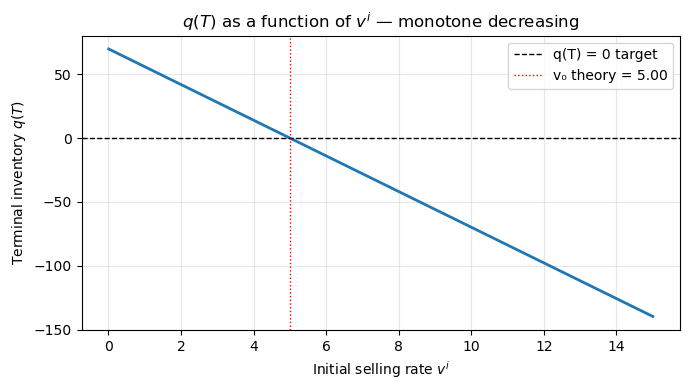

In [67]:
# Plot q(T) as a function of v0
v0_range = np.linspace(0.01, 3.0 * v0_theory, 80)
q_T_values = np.array([
    euler_solve(Q, T, v0_i, kap, N_euler)[1][-1]
    for v0_i in v0_range
])

plt.figure(figsize=(7, 4))
plt.plot(v0_range, q_T_values)
plt.axhline(0, color='k', linewidth=1, linestyle='--', label='q(T) = 0 target')
plt.axvline(v0_theory, color='red', linewidth=1, linestyle=':', label=f'v₀ theory = {v0_theory:.2f}')
plt.xlabel('Initial selling rate $v^i$')
plt.ylabel('Terminal inventory $q(T)$')
plt.title('$q(T)$ as a function of $v^i$ — monotone decreasing')
plt.legend()
plt.tight_layout()
plt.show()

### Question 4 : Shooting method

We use bisection on $v^i$ to find the unique value such that $q(T) = 0$.
We then compare the result to the analytical closed-form solution.

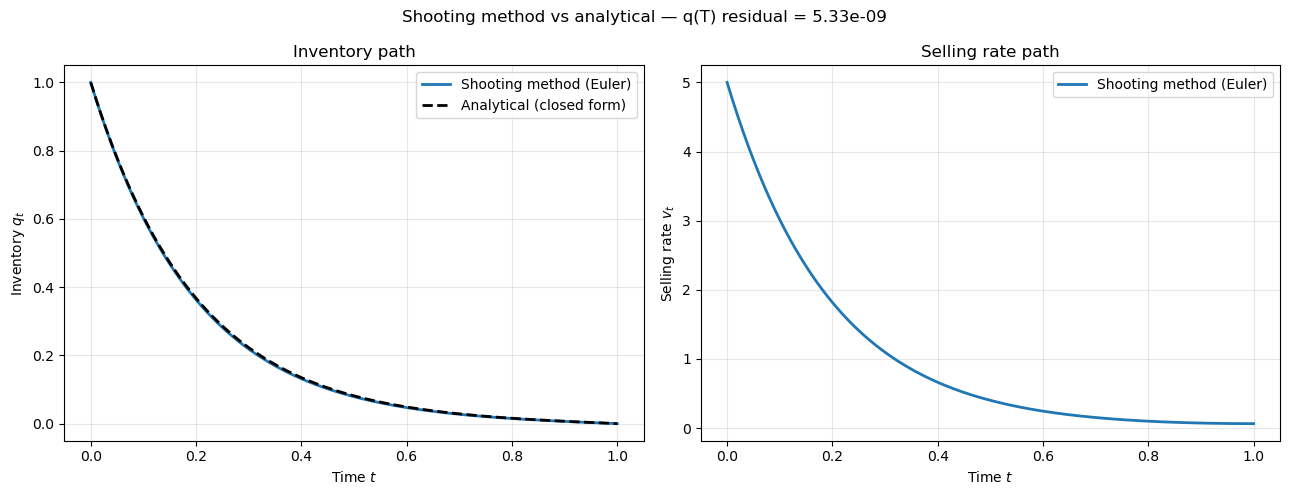

Terminal inventory after shooting: q(T) = 5.33e-09  (target: 0)
Initial selling rate found: v(0) = 5.0005  (analytical: 5.0005)


In [38]:
# Shooting method: find v0 such that q(T) = 0
t_shoot, q_shoot, v_shoot = shooting_method(Q, T, kap, N=N_euler)

# Analytical IS solution for comparison
t_exact, q_exact, _ = optimal_strategy_is(Q, T, sigma, eta, lam_euler)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(t_shoot, q_shoot, label='Shooting method (Euler)')
axes[0].plot(t_exact, q_exact, 'k--', label='Analytical (closed form)')
axes[0].set_xlabel('Time $t$')
axes[0].set_ylabel('Inventory $q_t$')
axes[0].set_title('Inventory path')
axes[0].legend()

axes[1].plot(t_shoot, v_shoot, label='Shooting method (Euler)')
axes[1].set_xlabel('Time $t$')
axes[1].set_ylabel('Selling rate $v_t$')
axes[1].set_title('Selling rate path')
axes[1].legend()

plt.suptitle(f'Shooting method vs analytical — q(T) residual = {q_shoot[-1]:.2e}', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Terminal inventory after shooting: q(T) = {q_shoot[-1]:.2e}  (target: 0)')
print(f'Initial selling rate found: v(0) = {v_shoot[0]:.4f}  (analytical: {v0_theory:.4f})')

### Setup

We now have two risky assets $S^1$ and $S^2$:
$$dS^1_t = \sigma_1\,dW^1_t, \qquad dS^2_t = \sigma_2\,dW^2_t, \qquad d\langle W^1,W^2\rangle_t = \rho\,dt$$

Initial positions: $q^1_0 = Q > 0$ (we hold $S^1$), $q^2_0 = 0$ (no position in $S^2$).  
We must liquidate everything: $q^1_T = q^2_T = 0$.

**Key parameters:**
- $\rho = 0.9$: high correlation between assets
- $\eta_2 < \eta_1$: $S^2$ is more liquid

**Intuition:** even though we hold no $S^2$, going short $S^2$ hedges the inventory risk of $S^1$ at a lower liquidity cost, because the two assets move together ($\rho$ high) and $S^2$ is cheaper to trade.

#### Objective

Following the course formalism, the criterion to maximise is:
$$\max_{v_1,\,v_2} \; \mathbb{E}[X_T - Q S^1_0] - \lambda\,\mathbb{V}[X_T - Q S^1_0]$$

This is equivalently written as a minimisation problem:
$$\min_{v_1,\,v_2} \; -\mathbb{E}[X_T - Q S^1_0] + \lambda\,\mathbb{V}[X_T - Q S^1_0]$$

We now derive each term explicitly.

#### Deriving $-\mathbb{E}[X_T - Q S^1_0]$

$X_t$ is the trader's cash account. Its dynamics are:
$$dX_t = \underbrace{q_1\,dS^1_t}_{\text{P\&L from holding }S^1} + \underbrace{q_2\,dS^2_t}_{\text{P\&L from holding }S^2} - \underbrace{\eta_1 v_1^2\,dt}_{\text{impact cost of trading }S^1} - \underbrace{\eta_2 v_2^2\,dt}_{\text{impact cost of trading }S^2}$$

Integrating over $[0,T]$:
$$X_T = X_0 + \int_0^T q_1\,dS^1_t + \int_0^T q_2\,dS^2_t - \eta_1\int_0^T v_1^2\,dt - \eta_2\int_0^T v_2^2\,dt$$

Subtracting the IS benchmark $Q S^1_0$:
$$X_T - Q S^1_0 = (X_0 - Q S^1_0) + \int_0^T q_1\,dS^1_t + \int_0^T q_2\,dS^2_t - \eta_1\int_0^T v_1^2\,dt - \eta_2\int_0^T v_2^2\,dt$$

Taking the expectation: we use the **arithmetic Brownian motion (Black model)** — prices have no drift, so $dS^i_t = \sigma_i\,dW^i_t$ is a martingale and $\mathbb{E}\!\left[\int_0^T q_i\,dS^i_t\right] = 0$. By convention $X_0 = Q S^1_0$ (Almgren-Chriss normalisation), so:
$$-\mathbb{E}[X_T - Q S^1_0] = \eta_1\int_0^T v_1^2\,dt + \eta_2\int_0^T v_2^2\,dt$$

#### Deriving $\mathbb{V}[X_T - Q S^1_0]$

From the expression above, $X_T - QS^1_0$ decomposes as:
$$X_T - Q S^1_0 = \underbrace{-\eta_1\int_0^T v_1^2\,dt - \eta_2\int_0^T v_2^2\,dt}_{\text{deterministic}} + \underbrace{\int_0^T q_1\,dS^1_t + \int_0^T q_2\,dS^2_t}_{\text{stochastic}}$$

Since strategies $q_1(t), q_2(t)$ are deterministic, only the stochastic part contributes to the variance:
$$\mathbb{V}[X_T - Q S^1_0] = \mathbb{E}\!\left[\left(\int_0^T q_1\,dS^1_t + \int_0^T q_2\,dS^2_t\right)^{\!2}\right]$$

Expanding the square:
$$= \mathbb{E}\!\left[\left(\int_0^T q_1\,dS^1_t\right)^{\!2}\right] + \mathbb{E}\!\left[\left(\int_0^T q_2\,dS^2_t\right)^{\!2}\right] + 2\,\mathbb{E}\!\left[\int_0^T q_1\,dS^1_t\cdot\int_0^T q_2\,dS^2_t\right]$$

Applying the **Itô isometry** to the diagonal terms ($dS^i_t = \sigma_i\,dW^i_t$):
$$\mathbb{E}\!\left[\left(\int_0^T q_i\,dS^i_t\right)^{\!2}\right] = \sigma_i^2\int_0^T q_i^2\,dt$$

For the cross term, using $d\langle S^1, S^2\rangle_t = \rho\sigma_1\sigma_2\,dt$:
$$\mathbb{E}\!\left[\int_0^T q_1\,dS^1_t\cdot\int_0^T q_2\,dS^2_t\right] = \rho\sigma_1\sigma_2\int_0^T q_1 q_2\,dt$$

Hence:
$$\mathbb{V}[X_T - Q S^1_0] = \sigma_1^2\int_0^T q_1^2\,dt + \sigma_2^2\int_0^T q_2^2\,dt + 2\rho\sigma_1\sigma_2\int_0^T q_1 q_2\,dt$$

#### Full optimisation problem

Plugging both terms into the criterion:
$$\boxed{\min_{v_1,\,v_2} \; \eta_1\int_0^T v_1^2\,dt + \eta_2\int_0^T v_2^2\,dt + \lambda\left(\sigma_1^2\int_0^T q_1^2\,dt + \sigma_2^2\int_0^T q_2^2\,dt + 2\rho\sigma_1\sigma_2\int_0^T q_1 q_2\,dt\right)}$$

The cross term $2\rho\sigma_1\sigma_2\int q_1 q_2\,dt$ is **negative** when $q_2 < 0$ (short $S^2$) — it directly reduces the variance penalty. The larger $\rho$, the stronger the hedge.

> **Generalisation to $n$ assets.** With assets $S^1,\ldots,S^n$, covariance matrix $\Sigma_{ij} = \rho_{ij}\sigma_i\sigma_j$, and diagonal impact matrix $H = \mathrm{diag}(\eta_1,\ldots,\eta_n)$:
> $$\min_{\mathbf{v}} \sum_{i=1}^n \eta_i\int_0^T v_i^2\,dt + \lambda\sum_{i=1}^n\sum_{j=1}^n \rho_{ij}\sigma_i\sigma_j\int_0^T q_i q_j\,dt$$
> or in matrix form:
> $$\min_{\mathbf{v}} \int_0^T \mathbf{v}^\top H\,\mathbf{v}\,dt + \lambda\int_0^T \mathbf{q}^\top \Sigma\,\mathbf{q}\,dt$$
> The 2-asset case above is the special case $n=2$.

### Question 1 : Bellman on a 2D grid

#### Why no closed-form solution?

In Section 1 (single asset), the Euler-Lagrange equation gave a single ODE $\ddot{q} = \kappa^2 q$ with an explicit $\sinh/\cosh$ solution.

With two assets, the optimality conditions give a **coupled system**:
$$\begin{cases} \eta_1\,\ddot{q}_1 = \lambda\left(\sigma_1^2\,q_1 + \rho\sigma_1\sigma_2\,q_2\right) \\ \eta_2\,\ddot{q}_2 = \lambda\left(\sigma_2^2\,q_2 + \rho\sigma_1\sigma_2\,q_1\right) \end{cases}$$

This is a **Boundary Value Problem (BVP)** — as opposed to an Initial Value Problem (IVP) where all conditions are given at $t=0$ and one integrates forward. In a BVP, conditions are imposed at **both ends** of the time interval:

$$q_1(0)=Q,\quad q_2(0)=0 \quad \text{(known at } t=0\text{)} \qquad q_1(T)=0,\quad q_2(T)=0 \quad \text{(imposed at } t=T\text{)}$$

The difficulty: to integrate the ODE system forward from $t=0$, one would also need $\dot{q}_1(0)$ and $\dot{q}_2(0)$, but these are **unknown** — they are part of the solution. For general $(\rho, \eta_1, \eta_2, \sigma_1, \sigma_2)$, finding them yields no clean closed form.

#### Why does Bellman work here?

Bellman backward induction sidesteps the BVP entirely by reformulating the problem as **dynamic programming**:

- Instead of integrating forward from $t=0$ with unknown initial conditions, we work **backwards from $T$**
- At $t=T$ the answer is trivial: $V[N, 0, 0] = 0$ (everything liquidated, zero cost), $+\infty$ otherwise
- At each earlier step $k$, we only ask: *"given my current state $(q_1, q_2)$, what is the best action $(n_1, n_2)$?"*, a simple minimisation over a finite grid
- The terminal constraint $q_1(T)=q_2(T)=0$ is enforced exactly by the boundary condition, with no need to guess initial velocities

This avoids the coupled ODE system altogether and works for any parameters.

#### The Bellman equation on the 2D grid

At each step $k$, the trader chooses $(n_1, n_2)$, the number of shares of $S^1$ sold and $S^2$ shorted, to minimise the sum of immediate cost and future cost-to-go:

$$V_k(q_1, q_2) = \min_{\substack{0 \le n_1 \le q_1 \\ n_2 \in \mathbb{R}}} \left[ \eta_1\!\left(\frac{n_1}{\Delta t}\right)^{\!2}\!\Delta t + \eta_2\!\left(\frac{n_2}{\Delta t}\right)^{\!2}\!\Delta t + \lambda\Bigl(\sigma_1^2 q_1^2 + \sigma_2^2 q_2^2 + 2\rho\sigma_1\sigma_2\,q_1 q_2\Bigr)\Delta t + V_{k+1}(q_1 - n_1,\; q_2 - n_2) \right]$$

with $V_N(0,0) = 0$ and $V_N(q_1, q_2) = +\infty$ otherwise.

Compared to the 1D Bellman (Section 1):
- **Two actions** $(n_1, n_2)$: $n_1 \ge 0$ (can only sell $S^1$), but $n_2$ is free — the trader can short $S^2$ ($n_2 < 0$ means increasing a short position).
- **Cross term** $2\rho\sigma_1\sigma_2\,q_1 q_2$ in the running cost: when $q_2 < 0$ and $\rho > 0$, this term is negative, directly reducing the inventory risk — that is the hedge.
- **Complexity**: the state space is $O(n_q^2)$ and actions are $O(n_q^2)$ per state, so total cost is $O(N \cdot n_q^4)$ — keep $n_q$ small (20–30).

**Sanity check:** setting $q_2 = 0$ and $\sigma_1=\sigma$, $\eta_1=\eta$ recovers exactly the single-asset IS Bellman equation from Section 1, the cross term vanishes and the $\eta_2$ term drops out.

Running two-asset Bellman...
Done.
S2 min position: -0.60  (negative = short hedge)
S2 final position: 0.00  (must be 0)


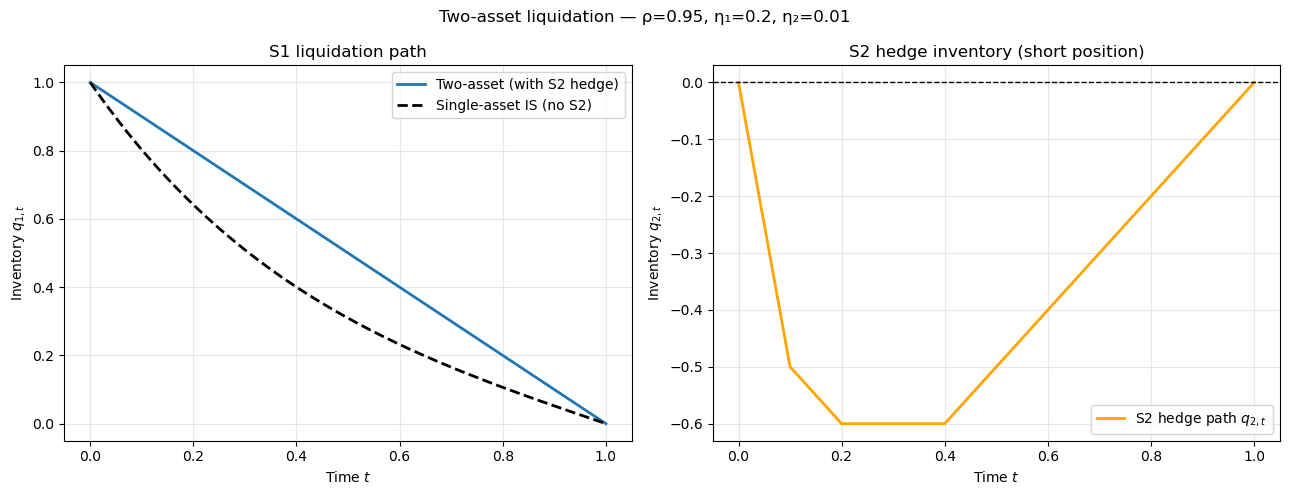

In [39]:
# Two-asset parameters
# The hedge is beneficial when lambda is large (risk-averse) and eta2 << eta1
Q_s1   = 1.0    # initial inventory of S1 (S2 starts at 0 by definition)
T      = 1.0    # liquidation horizon (same as Section 1)
sigma1 = 0.3    # volatility of S1
sigma2 = 0.3    # volatility of S2
rho    = 0.95   # correlation between S1 and S2 (very high: S2 is a close substitute)
eta1   = 0.2    # temporary impact of S1 (illiquid)
eta2   = 0.01   # temporary impact of S2 (20x more liquid than S1)
lam    = 10.0   # risk-aversion coefficient (high to show hedge benefit)
N      = 10     # number of time steps
n_q    = 10     # grid size per asset — finer grid for smoother paths (complexity: O(N * n_q^4))

print('Running two-asset Bellman...')
t, q1_grid, q2_grid, q1_path, q2_path = bellman_two_assets(
    Q_s1, T, sigma1, sigma2, rho, eta1, eta2, lam, N=N, n_q=n_q
)
print('Done.')
print(f'S2 min position: {q2_path.min():.2f}  (negative = short hedge)')
print(f'S2 final position: {q2_path[-1]:.2f}  (must be 0)')

# Single-asset IS benchmark (no access to S2)
t_is_single, q_is_single, _ = optimal_strategy_is(Q_s1, T, sigma1, eta1, lam)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(t, q1_path, label='Two-asset (with S2 hedge)')
axes[0].plot(t_is_single, q_is_single, 'k--', label='Single-asset IS (no S2)')
axes[0].set_xlabel('Time $t$')
axes[0].set_ylabel('Inventory $q_{1,t}$')
axes[0].set_title('S1 liquidation path')
axes[0].legend()

axes[1].plot(t, q2_path, color='orange', label='S2 hedge path $q_{2,t}$')
axes[1].axhline(0, color='k', linewidth=1, linestyle='--')
axes[1].set_xlabel('Time $t$')
axes[1].set_ylabel('Inventory $q_{2,t}$')
axes[1].set_title('S2 hedge inventory (short position)')
axes[1].legend()

plt.suptitle(
    f'Two-asset liquidation — ρ={rho}, η₁={eta1}, η₂={eta2}',
    fontsize=12
)
plt.tight_layout()
plt.show()

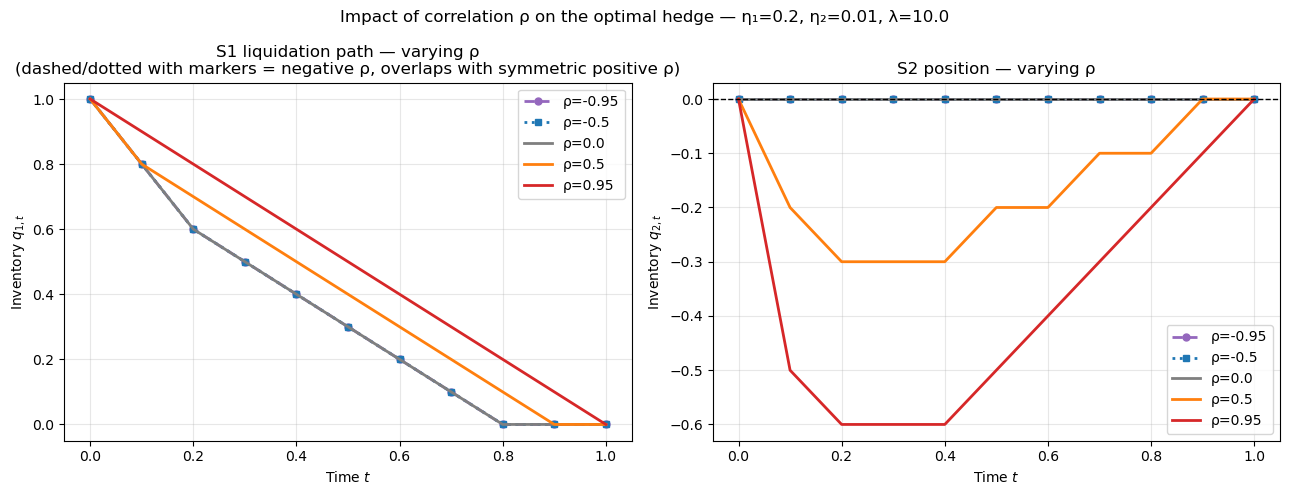

In [40]:
# Sensitivity to correlation rho — now including negative values
rhos       = [-0.95, -0.5, 0.0, 0.5, 0.95]
colors_rho = ['tab:purple', 'tab:blue', 'tab:gray', 'tab:orange', 'tab:red']
styles_rho = ['--', ':', '-', '-', '-']
markers    = ['o', 's', None, None, None]  # markers on negative rho to show they overlap with positive

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for rho_i, color, style, marker in zip(rhos, colors_rho, styles_rho, markers):
    t_i, _, _, q1_i, q2_i = bellman_two_assets(
        Q_s1, T, sigma1, sigma2, rho_i, eta1, eta2, lam, N=N, n_q=n_q
    )
    axes[0].plot(t_i, q1_i, color=color, linestyle=style, marker=marker, markersize=5, label=f'ρ={rho_i}')
    axes[1].plot(t_i, q2_i, color=color, linestyle=style, marker=marker, markersize=5, label=f'ρ={rho_i}')

axes[0].set_xlabel('Time $t$')
axes[0].set_ylabel('Inventory $q_{1,t}$')
axes[0].set_title('S1 liquidation path — varying ρ\n(dashed/dotted with markers = negative ρ, overlaps with symmetric positive ρ)')
axes[0].legend()

axes[1].axhline(0, color='k', linewidth=1, linestyle='--')
axes[1].set_xlabel('Time $t$')
axes[1].set_ylabel('Inventory $q_{2,t}$')
axes[1].set_title('S2 position — varying ρ')
axes[1].legend()

plt.suptitle(f'Impact of correlation ρ on the optimal hedge — η₁={eta1}, η₂={eta2}, λ={lam}', fontsize=12)
plt.tight_layout()
plt.show()

**Reading the ρ sensitivity:**
- **ρ = 0**: $S^2$ is uncorrelated with $S^1$ — no hedge benefit, the optimal $q_{2,t} = 0$. $S^1$ is liquidated as in the single-asset case.
- **ρ > 0**: the trader **shorts** $S^2$ ($q_2 < 0$) to offset $S^1$ risk via the cross term $2\rho\sigma_1\sigma_2 q_1 q_2 < 0$. The higher $\rho$, the deeper the short and the slower the $S^1$ liquidation.
- **ρ < 0**: the trader **longs** $S^2$ ($q_2 > 0$) — when $S^1$ goes down, $S^2$ goes up, so holding $S^2$ offsets the loss. The cross term $2\rho\sigma_1\sigma_2 q_1 q_2 < 0$ again (negative $\rho$, positive $q_2$). The hedge is symmetric: the sign of $q_2$ always follows the sign of $-\rho$.
- **|ρ| = 0.95**: the hedge is strongest in both directions — the trader can almost fully transfer $S^1$ risk onto the cheaper $S^2$.

### Question 2 : Impact of the hedge on the optimal strategy

We compare two strategies:
- **Single-asset IS**: the trader can only sell $S^1$, optimal strategy from Section 1.
- **Two-asset**: the trader can also trade $S^2$, optimal strategy from the 2D Bellman above.

Both strategies liquidate $S^1$ from $Q$ to $0$ over $[0,T]$. The question is: **does access to $S^2$ reduce the total portfolio variance, and at what additional liquidity cost?**

We use the variance formula derived in the Setup:
$$\mathbb{V}[\text{payoff}] = \sigma_1^2\int_0^T q_1^2\,dt + \sigma_2^2\int_0^T q_2^2\,dt + 2\rho\sigma_1\sigma_2\int_0^T q_1 q_2\,dt$$

For the single-asset benchmark, $q_2 = 0$ everywhere, so the last two terms vanish and we recover $\sigma_1^2\int_0^T q_1^2\,dt$.

In [41]:
dt = T / N

# Portfolio variance with the two-asset strategy
var_two = (
    sigma1**2 * np.trapezoid(q1_path**2, t)
    + sigma2**2 * np.trapezoid(q2_path**2, t)
    + 2 * rho * sigma1 * sigma2 * np.trapezoid(q1_path * q2_path, t)
)

# Portfolio variance with single-asset IS (no hedge)
var_single = sigma1**2 * np.trapezoid(q_is_single**2, t_is_single)

# Liquidity costs
v1_two = -np.diff(q1_path) / dt
v2_two = -np.diff(q2_path) / dt
cost_two = eta1 * np.sum(v1_two**2) * dt + eta2 * np.sum(v2_two**2) * dt

_, cost_single, var_single_check = (
    None,
    *cost_and_variance_is(q_is_single, np.gradient(q_is_single, t_is_single) * (-1), t_is_single, sigma1, eta1)
)

print('─' * 45)
print(f'  Strategy          | Variance  | Cost')
print('─' * 45)
print(f'  Single-asset IS   | {var_single:.4f}    | {cost_single:.4f}')
print(f'  Two-asset + hedge | {var_two:.4f}    | {cost_two:.4f}')
print('─' * 45)
print(f'  Variance reduction: {100*(var_single - var_two)/var_single:.1f}%')

─────────────────────────────────────────────
  Strategy          | Variance  | Cost
─────────────────────────────────────────────
  Single-asset IS   | 0.0192    | 0.2449
  Two-asset + hedge | 0.0084    | 0.2320
─────────────────────────────────────────────
  Variance reduction: 56.1%


**Interpretation:**
- Access to the more liquid, highly correlated asset $S^2$ allows the trader to hedge inventory risk at a lower cost.
- The optimal strategy shorts $S^2$ early (when $q^1$ is large) to offset $S^1$ exposure, then buys back $S^2$ as $S^1$ is liquidated.
- The cross term $2\rho\sigma_1\sigma_2\int q_1 q_2\,dt$ is negative (since $q_2 < 0$), directly reducing portfolio variance.
- The trade-off: shorting $S^2$ has a liquidity cost ($\eta_2 > 0$), but since $\eta_2 \ll \eta_1$, the net effect is a variance reduction with modest additional cost.

---
## Section 4 (Bonus) : Neural Networks for Optimal Liquidation

### Motivation

The closed-form solutions of Section 1 rely on:
- Linear temporary impact
- Arithmetic Brownian motion for the asset price
- mean-variance criterion with deterministic optimal schedules for IS and TC

Neural networks provide a flexible numerical framework to approximate optimal liquidation strategies without explicitly solving the associated Euler-Lagrange equations or Bellman equations. They are especially useful when the model is enriched with additional state variables or more realistic constraints, for which no closed-form solution is available.

### Approach for IS and TC

In the Almgren–Chriss setting, the IS and TC problems are static: once the parameters are fixed, the optimal strategy is a deterministic liquidation curve. Therefore, instead of training a generic feedback policy by Monte Carlo simulation, we directly parameterise the liquidation schedule on a discrete time grid.

More precisely, the neural network outputs one score per time interval. A softmax transformation converts these scores into nonnegative weights


More precisely, the neural network outputs one score per time interval. A softmax transformation converts these scores into nonnegative weights
$$
w_k \ge 0, \qquad \sum_{k=0}^{N-1} w_k = 1
$$
We then define the quantity traded on interval \(k\) by
$$
x_k = Qw_k
$$
so that
$$
\sum_{k=0}^{N-1} x_k = Q.
$$
Hence, the full liquidation constraint is enforced **exactly by construction**, without clipping or terminal penalty.
    
This is better adapted to IS and TC than the previous Monte Carlo feedback-policy formulation, because the corresponding objective is already a deterministic functional of the inventory path.
### Validation principle
For IS and TC, the neural network strategies can be compared directly with the analytical closed-form solutions obtained in Section 1. This provides a natural benchmark to assess the quality of the approximation.

In [42]:
from neural_network import train_static_policy, extract_static_strategy

# Shared parameters (same as Section 1)
Q_nn, T_nn, sigma_nn, eta_nn, lam_nn = 1.0, 1.0, 0.3, 0.1, 1.0

# Discretization / training parameters
N_nn = 200
n_epochs_nn = 3000
lr_nn = 5e-3
hidden_size_nn = 64

print("Training IS policy...")
policy_is, losses_is = train_static_policy(
    order_type="IS",
    Q=Q_nn,
    T=T_nn,
    sigma=sigma_nn,
    eta=eta_nn,
    lam=lam_nn,
    N=N_nn,
    n_epochs=n_epochs_nn,
    lr=lr_nn,
    hidden_size=hidden_size_nn,
    seed=42,
    device="cpu",
)

print("\nTraining TC policy...")
policy_tc, losses_tc = train_static_policy(
    order_type="TC",
    Q=Q_nn,
    T=T_nn,
    sigma=sigma_nn,
    eta=eta_nn,
    lam=lam_nn,
    N=N_nn,
    n_epochs=n_epochs_nn,
    lr=lr_nn,
    hidden_size=hidden_size_nn,
    seed=42,
    device="cpu",
)

# Neural strategies
t_nn_is, q_nn_is, v_nn_is = extract_static_strategy(policy_is, Q_nn, T_nn, N_nn)
t_nn_tc, q_nn_tc, v_nn_tc = extract_static_strategy(policy_tc, Q_nn, T_nn, N_nn)

# Analytical closed-form strategies from Section 1
t_an_is, q_an_is, v_an_is = optimal_strategy_is(Q_nn, T_nn, sigma_nn, eta_nn, lam_nn)
t_an_tc, q_an_tc, v_an_tc = optimal_strategy_tc(Q_nn, T_nn, sigma_nn, eta_nn, lam_nn)

Training IS policy...
[IS] Epoch 500/3000 — loss = 0.12834173
[IS] Epoch 1000/3000 — loss = 0.12834145
[IS] Epoch 1500/3000 — loss = 0.12834144
[IS] Epoch 2000/3000 — loss = 0.12834144
[IS] Epoch 2500/3000 — loss = 0.12834143
[IS] Epoch 3000/3000 — loss = 0.12834142

Training TC policy...
[TC] Epoch 500/3000 — loss = 0.12834143
[TC] Epoch 1000/3000 — loss = 0.12834142
[TC] Epoch 1500/3000 — loss = 0.12834142
[TC] Epoch 2000/3000 — loss = 0.12834142
[TC] Epoch 2500/3000 — loss = 0.12834147
[TC] Epoch 3000/3000 — loss = 0.12834142


In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(losses_is, label='IS')
plt.plot(losses_tc, label='TC')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Neural network training loss (deterministic schedule)')
plt.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t_nn_is, q_nn_is, label='Neural network')
axes[0].plot(t_an_is, q_an_is, 'k--', label='Analytical (closed form)')
axes[0].set_title('IS order')
axes[0].set_xlabel('Time t')
axes[0].set_ylabel('Inventory q_t')
axes[0].legend()

axes[1].plot(t_nn_tc, q_nn_tc, label='Neural network')
axes[1].plot(t_an_tc, q_an_tc, 'k--', label='Analytical (closed form)')
axes[1].set_title('TC order')
axes[1].set_xlabel('Time t')
axes[1].set_ylabel('Inventory q_t')
axes[1].legend()

plt.suptitle('Neural-network schedules vs closed-form solutions', fontsize=12)
plt.tight_layout()
plt.show()


print(f"IS: terminal inventory q(T) = {q_nn_is[-1]:.6e}")
print(f"TC: terminal inventory q(T) = {q_nn_tc[-1]:.6e}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t_nn_is[:-1], v_nn_is, label='Neural network')
axes[0].plot(t_an_is, v_an_is, 'k--', label='Analytical (closed form)')
axes[0].set_title('IS selling rate')
axes[0].set_xlabel('Time t')
axes[0].set_ylabel('Selling rate v_t')
axes[0].legend()

axes[1].plot(t_nn_tc[:-1], v_nn_tc, label='Neural network')
axes[1].plot(t_an_tc, v_an_tc, 'k--', label='Analytical (closed form)')
axes[1].set_title('TC selling rate')
axes[1].set_xlabel('Time t')
axes[1].set_ylabel('Selling rate v_t')
axes[1].legend()

plt.suptitle('Selling rates: neural network vs analytical solution', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Interpolate analytical inventories onto the neural grids
q_an_is_interp = np.interp(t_nn_is, t_an_is, q_an_is)
q_an_tc_interp = np.interp(t_nn_tc, t_an_tc, q_an_tc)

# Supremum norm and RMSE
err_inf_is = np.max(np.abs(q_nn_is - q_an_is_interp))
err_inf_tc = np.max(np.abs(q_nn_tc - q_an_tc_interp))

err_rmse_is = np.sqrt(np.mean((q_nn_is - q_an_is_interp) ** 2))
err_rmse_tc = np.sqrt(np.mean((q_nn_tc - q_an_tc_interp) ** 2))

print("Inventory path errors")
print(f"IS : ||q_NN - q*||_inf = {err_inf_is:.6e},   RMSE = {err_rmse_is:.6e}")
print(f"TC : ||q_NN - q*||_inf = {err_inf_tc:.6e},   RMSE = {err_rmse_tc:.6e}")

print("\nTerminal inventories")
print(f"IS : q_NN(T) = {q_nn_is[-1]:.6e}")
print(f"TC : q_NN(T) = {q_nn_tc[-1]:.6e}")

In [ ]:
def discrete_objective_is(q_path, T, sigma, eta, lam):
    q_path = np.asarray(q_path)
    N = len(q_path) - 1
    dt = T / N
    x = q_path[:-1] - q_path[1:]
    v = x / dt
    q_mid = q_path[:-1] - 0.5 * x
    return eta * np.sum(v**2) * dt + lam * sigma**2 * np.sum(q_mid**2) * dt


def discrete_objective_tc(q_path, Q, T, sigma, eta, lam):
    q_path = np.asarray(q_path)
    N = len(q_path) - 1
    dt = T / N
    x = q_path[:-1] - q_path[1:]
    v = x / dt
    q_mid = q_path[:-1] - 0.5 * x
    sold_mid = Q - q_mid
    return eta * np.sum(v**2) * dt + lam * sigma**2 * np.sum(sold_mid**2) * dt


J_nn_is = discrete_objective_is(q_nn_is, T_nn, sigma_nn, eta_nn, lam_nn)
J_an_is = discrete_objective_is(q_an_is_interp, T_nn, sigma_nn, eta_nn, lam_nn)

J_nn_tc = discrete_objective_tc(q_nn_tc, Q_nn, T_nn, sigma_nn, eta_nn, lam_nn)
J_an_tc = discrete_objective_tc(q_an_tc_interp, Q_nn, T_nn, sigma_nn, eta_nn, lam_nn)

print("Objective values")
print(f"IS : J(NN) = {J_nn_is:.8f},   J(analytic interp) = {J_an_is:.8f},   relative gap = {(J_nn_is - J_an_is)/J_an_is:.6%}")
print(f"TC : J(NN) = {J_nn_tc:.8f},   J(analytic interp) = {J_an_tc:.8f},   relative gap = {(J_nn_tc - J_an_tc)/J_an_tc:.6%}")

### Results
    
The training losses for both IS and TC decrease rapidly and then stabilize, which indicates that the optimization procedure converges in a stable way.
    
The neural-network schedules are then compared with the analytical closed-form solutions derived in Section 1. In both cases, the inventory trajectories and selling-rate curves are almost indistinguishable from the theoretical benchmarks. This shows that the neural parametrization successfully recovers the optimal liquidation profiles.
    
The approximation errors are extremely small. For the **IS order**, we obtain
$$
\|q^{NN} - q^\star\|_\infty = 2.38 \times 10^{-5}
\qquad
\mathrm{RMSE} = 1.45 \times 10^{-5}.
$$
For the **TC order**, we obtain
$$
\|q^{NN} - q^\star\|_\infty = 2.63 \times 10^{-5},
\qquad
\mathrm{RMSE} = 1.52 \times 10^{-5}.
$$
    
Moreover, the terminal inventories are
$$
q^{NN}_{IS}(T) = -2.22 \times 10^{-16},
\qquad
q^{NN}_{TC}(T) = -6.66 \times 10^{-16},
$$
which is numerically equal to zero up to machine precision. This confirms that the liquidation constraint is enforced exactly by construction.
    
Overall, these results provide a strong validation of the method: in the static Almgren–Chriss setting, the neural-network parametrization of the liquidation schedule is able to recover the analytical IS and TC optimal strategies with very high accuracy.
   